Cell 1: Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2: Import Libraries

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

Cell 3: Check GPU

In [ ]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Cell 4: Dataset Path

In [ ]:
train_dir = "/content/drive/MyDrive/datasets/Brain Tumor Classification/train"
test_dir = "/content/drive/MyDrive/datasets/Brain Tumor Classification/test"

# Verify if the directories exist before listing their contents
if not os.path.exists(train_dir):
    print(f"Error: Training directory not found at {train_dir}")
else:
    print("Train directory contents:", os.listdir(train_dir))

if not os.path.exists(test_dir):
    print(f"Error: Test directory not found at {test_dir}")
else:
    print("Test directory contents:", os.listdir(test_dir))

Train directory contents: ['meningioma_tumor', 'glioma_tumor', 'pituitary_tumor', 'normal']
Test directory contents: ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor', 'normal']


Cell 5: Count Images and Class Distribution

In [ ]:
def count_images(directory):
    class_counts = {}
    total = 0

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            class_counts[class_name] = count
            total += count

    return class_counts, total

train_counts, train_total = count_images(train_dir)
test_counts, test_total = count_images(test_dir)

print("Training images:", train_total)
print(train_counts)

print("\nTest images:", test_total)
print(test_counts)

Training images: 2447
{'meningioma_tumor': 723, 'glioma_tumor': 713, 'pituitary_tumor': 668, 'normal': 343}

Test images: 621
{'glioma_tumor': 181, 'meningioma_tumor': 183, 'pituitary_tumor': 169, 'normal': 88}


Cell 6: Plot Class Distribution

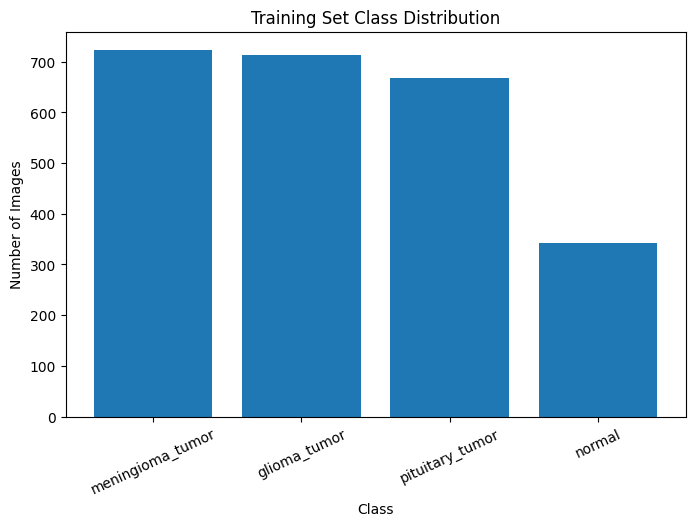

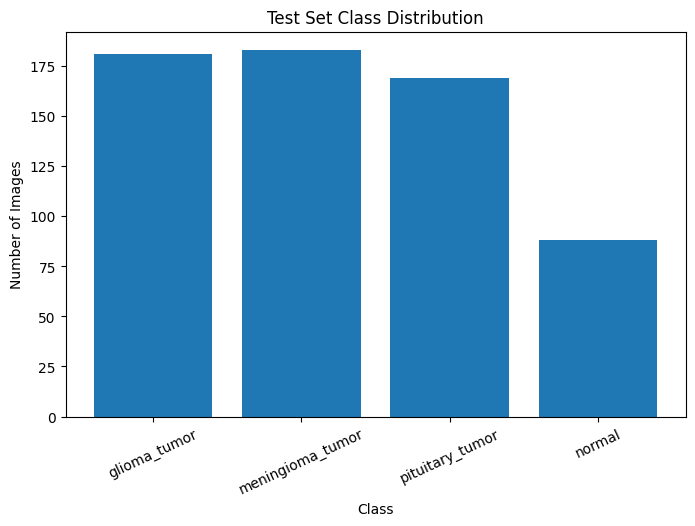

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=25)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(test_counts.keys(), test_counts.values())
plt.title("Test Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=25)
plt.show()

Cell 7: Data Generators with Augmentation

In [ ]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


Cell 8: Show Sample Augmented Images

Attempting to diagnose UnidentifiedImageError...
No immediate corrupted or unidentified image files found in the first batch of checks.
Proceeding to load and display sample augmented images...


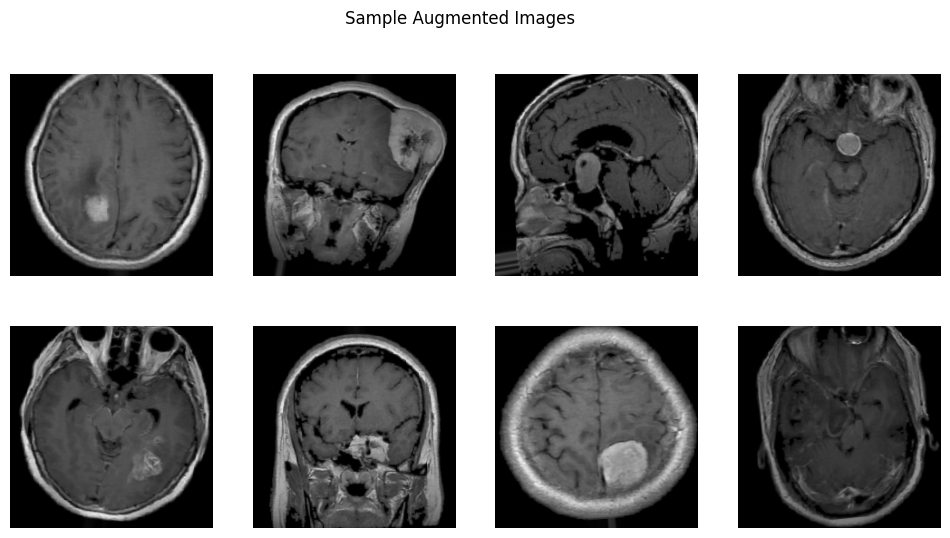

In [ ]:
import PIL.Image

print("Attempting to diagnose UnidentifiedImageError...")
problem_found = False

# train_generator.filepaths contains the absolute paths to the images the generator will use.
# We'll check a subset of these files to avoid excessive runtime if the dataset is very large.
num_files_to_check = min(len(train_generator.filepaths), 200) # Check up to 200 files

for i in range(num_files_to_check):
    filepath = train_generator.filepaths[i]
    try:
        # Using 'rb' mode to read as binary and .verify() to check image integrity
        # .close() is called implicitly when exiting 'with' block
        with open(filepath, 'rb') as f:
            img = PIL.Image.open(f)
            img.verify() # Verify image integrity
            img.close() # Close the image file
    except (PIL.UnidentifiedImageError, OSError) as e:
        print(f"\nError identified in file: {filepath}")
        print(f"Details: {e}")
        print("This file appears to be corrupted or is not a valid image format.")
        problem_found = True
        break # Stop after finding the first problematic file
    except Exception as e:
        print(f"\nAn unexpected error occurred when checking file {filepath}: {e}")
        problem_found = True
        break

if problem_found:
    print("\nPlease remove or fix the problematic file(s) from your dataset and re-run the cells.")
else:
    print("No immediate corrupted or unidentified image files found in the first batch of checks.")
    print("Proceeding to load and display sample augmented images...")
    try:
        images, labels = next(train_generator)

        plt.figure(figsize=(12, 6))
        for i in range(8):
            plt.subplot(2, 4, i + 1)
            plt.imshow(images[i])
            plt.axis("off")

        plt.suptitle("Sample Augmented Images")
        plt.show()
    except UnidentifiedImageError as e:
        print(f"\nUnidentifiedImageError still occurred when trying to get a batch: {e}")
        print("This might indicate deeper issues with data generation or corrupt files not caught in the initial check.")
    except Exception as e:
        print(f"\nAn unexpected error occurred during batch generation: {e}")


**Baseline CNN Model**

Cell 9: Build Baseline CNN

In [ ]:
from tensorflow.keras.regularizers import l2

num_classes = train_generator.num_classes

baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

baseline_model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,269,060 (50.62 MB)

 Trainable params: 13,268,100 (50.61 MB)

 Non-trainable params: 960 (3.75 KB)

Cell 10: Train Baseline CNN

In [ ]:
import os
from PIL import Image

def remove_bad_images(folder):
    bad_files = []

    for root, dirs, files in os.walk(folder):
        for file in files:
            file_path = os.path.join(root, file)

            try:
                img = Image.open(file_path)
                img.verify()
            except:
                bad_files.append(file_path)
                os.remove(file_path)

    return bad_files

bad_train = remove_bad_images(train_dir)
bad_test = remove_bad_images(test_dir)

print("Bad train files removed:", len(bad_train))
print("Bad test files removed:", len(bad_test))

print(bad_train[:10])
print(bad_test[:10])

# Re-initialize generators after removing bad images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Re-introduce model training to define baseline_history
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

baseline_time = time.time() - start_time
print("Baseline Training Time:", baseline_time, "seconds")

Bad train files removed: 0
Bad test files removed: 0
[]
[]
Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 61s 780ms/step - accuracy: 0.4173 - loss: 2.3463 - val_accuracy: 0.2916 - val_loss: 3.7271
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 634ms/step - accuracy: 0.5071 - loss: 1.8322 - val_accuracy: 0.2916 - val_loss: 5.9228
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 632ms/step - accuracy: 0.5082 - loss: 1.7982 - val_accuracy: 0.2916 - val_loss: 6.2105
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 37s 605ms/step - accuracy: 0.5383 - loss: 1.7198 - val_accuracy: 0.3101 - val_loss: 5.2415
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 38s 627ms/step - accuracy: 0.5832 - loss: 1.6860 - val_accuracy: 0.3593 - val_loss: 4.3571
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 665ms/step - accuracy: 0.5959 - loss: 1.5921 - val_accuracy: 0.3778 - val_loss: 3.8440
Baseline Training Time: 257.794869184494 seconds


Cell 11: Plot Baseline Accuracy and Loss

In [ ]:
import time
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

baseline_time = time.time() - start_time
print("Baseline Training Time:", baseline_time, "seconds")

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 652ms/step - accuracy: 0.5199 - loss: 1.8525 - val_accuracy: 0.2916 - val_loss: 4.6612
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 38s 621ms/step - accuracy: 0.5224 - loss: 1.7754 - val_accuracy: 0.2916 - val_loss: 6.0746
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 37s 597ms/step - accuracy: 0.5663 - loss: 1.6941 - val_accuracy: 0.3203 - val_loss: 6.3444
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 624ms/step - accuracy: 0.5898 - loss: 1.6370 - val_accuracy: 0.3491 - val_loss: 4.5195
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 658ms/step - accuracy: 0.6046 - loss: 1.5878 - val_accuracy: 0.4004 - val_loss: 3.3052
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 628ms/step - accuracy: 0.6321 - loss: 1.5325 - val_accuracy: 0.4435 - val_loss: 2.6171
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 37s 600ms/step - accuracy: 0.6449 - loss: 1.5179 - val_accuracy: 0.4333 - val_loss: 2.2750
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 627ms/step - accuracy: 0.6566 - loss: 1.4649 - val_accu

Cell 12: Evaluate Baseline Model

In [ ]:
baseline_loss, baseline_acc = baseline_model.evaluate(test_generator)

print("Baseline Test Accuracy:", baseline_acc)
print("Baseline Test Loss:", baseline_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - accuracy: 0.8309 - loss: 1.0867
Baseline Test Accuracy: 0.8309178948402405
Baseline Test Loss: 1.0866754055023193


Cell 13: Classification Report for Baseline

In [ ]:
y_pred = baseline_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_names))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.92      0.81      0.86       181
meningioma_tumor       0.82      0.68      0.74       183
          normal       0.81      0.88      0.84        88
 pituitary_tumor       0.78      0.99      0.87       169

        accuracy                           0.83       621
       macro avg       0.83      0.84      0.83       621
    weighted avg       0.84      0.83      0.83       621



Cell 14: Confusion Matrix

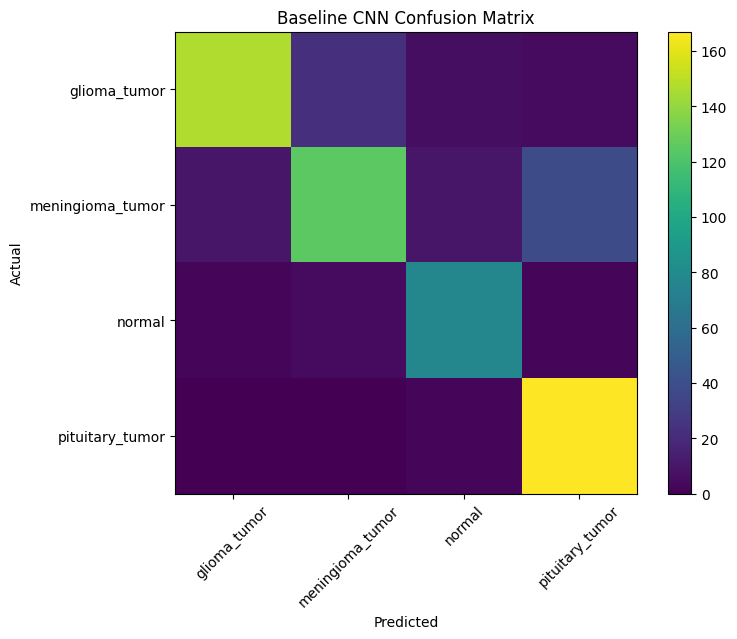

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Baseline CNN Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Cell 15: Prediction on Sample Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step


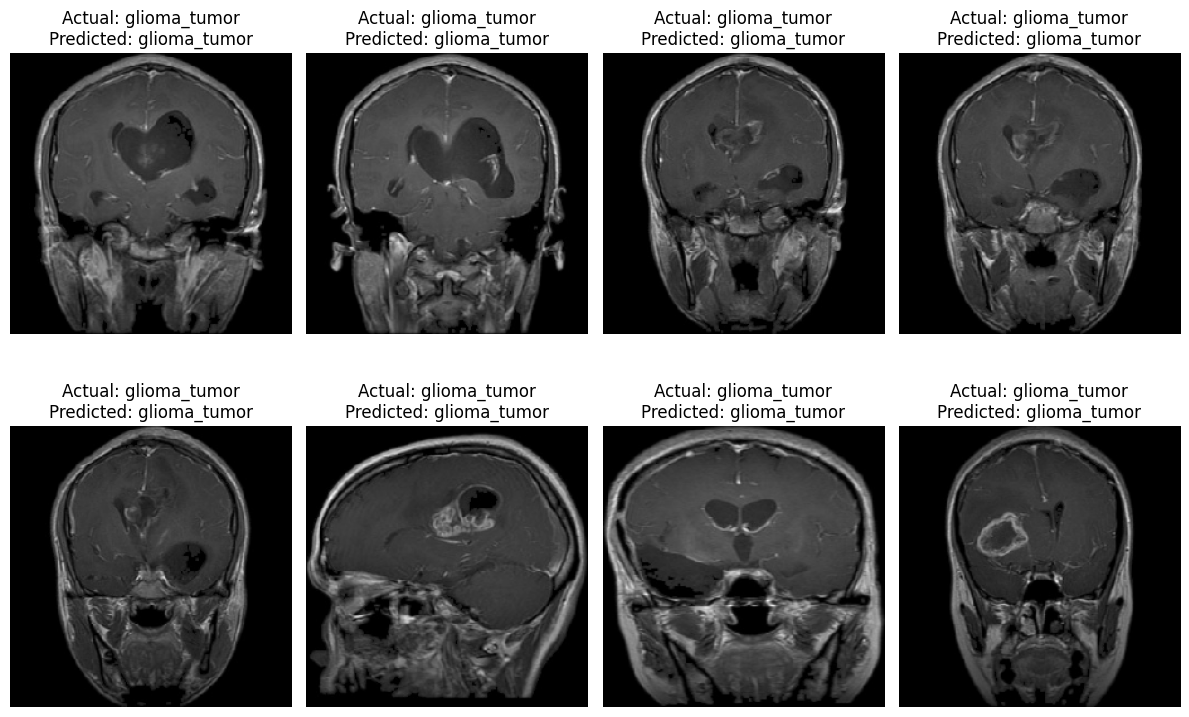

In [ ]:
images, labels = next(test_generator)
predictions = baseline_model.predict(images)

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    actual = class_names[np.argmax(labels[i])]
    predicted = class_names[np.argmax(predictions[i])]
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Baseline accuracy/loss graph**

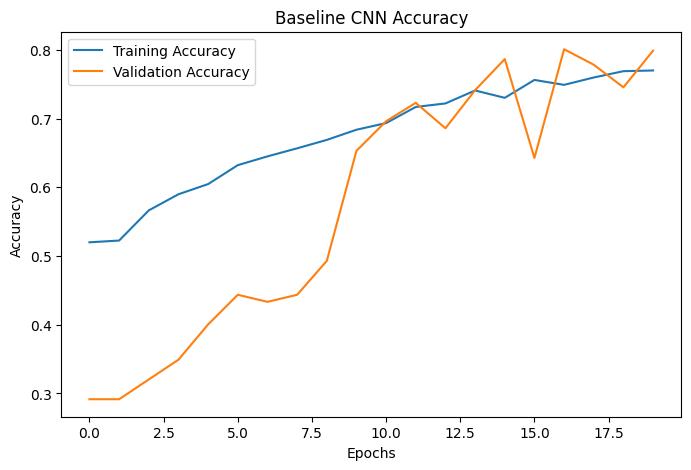

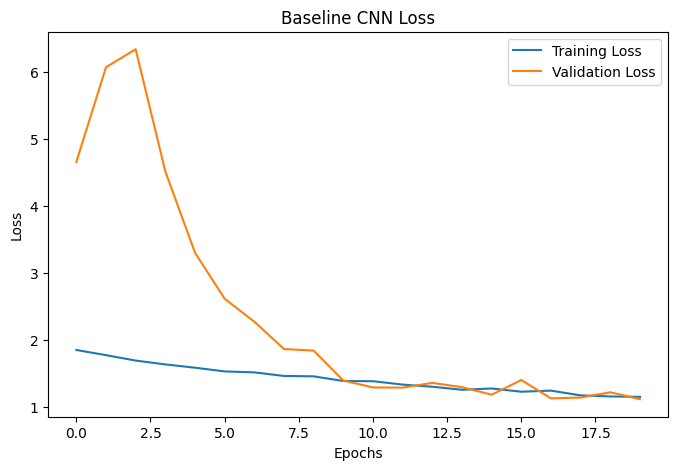

In [34]:
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history['accuracy'], label='Training Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(baseline_history.history['loss'], label='Training Loss')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss')
plt.title("Baseline CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Deeper CNN with Regularization**

Cell 16: Build Deeper CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

deep_model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0001)),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0001)),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

deep_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,080,644 (4.12 MB)

 Trainable params: 1,079,172 (4.12 MB)

 Non-trainable params: 1,472 (5.75 KB)

Cell 17: Train Deeper CNN

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

early_stop_deep = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7
)

start_time = time.time()

deep_history = deep_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop_deep, reduce_lr]
)

deep_time = time.time() - start_time
print("Deeper Model Training Time:", deep_time, "seconds")

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 652ms/step - accuracy: 0.8189 - loss: 0.5056 - val_accuracy: 0.7207 - val_loss: 0.6519 - learning_rate: 3.0000e-05
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 652ms/step - accuracy: 0.8214 - loss: 0.5064 - val_accuracy: 0.7906 - val_loss: 0.5592 - learning_rate: 3.0000e-05
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 644ms/step - accuracy: 0.8306 - loss: 0.4984 - val_accuracy: 0.7864 - val_loss: 0.5937 - learning_rate: 3.0000e-05
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 631ms/step - accuracy: 0.8342 - loss: 0.4763 - val_accuracy: 0.7680 - val_loss: 0.6184 - learning_rate: 3.0000e-05
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 649ms/step - accuracy: 0.8281 - loss: 0.4693 - val_accuracy: 0.7700 - val_loss: 0.6253 - learning_rate: 3.0000e-05
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 676ms/step - accuracy: 0.8342 - loss: 0.4551 - val_accuracy: 0.8029 - val_loss: 0.5247 - learning_rate: 9.0000e-06
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 695ms/step - acc

Cell 18: Plot Deeper Model Accuracy and Loss

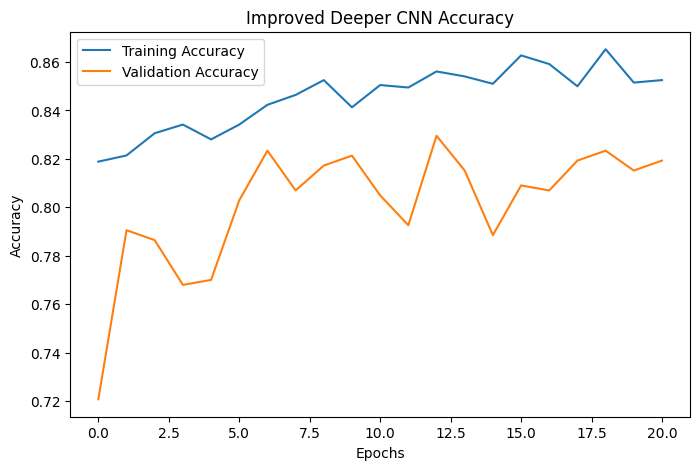

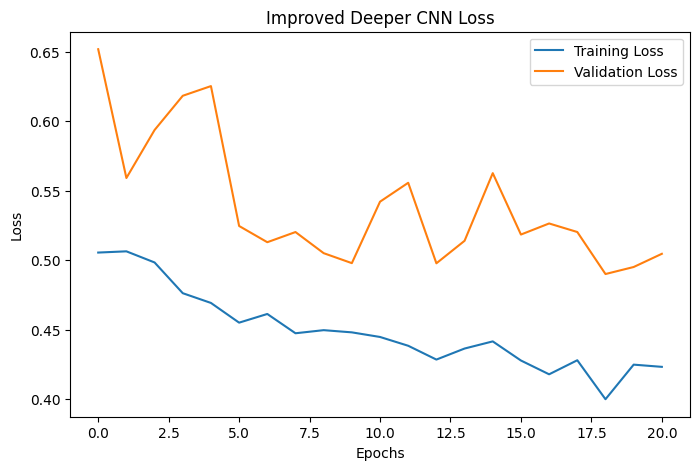

In [28]:
plt.figure(figsize=(8,5))
plt.plot(deep_history.history['accuracy'], label='Training Accuracy')
plt.plot(deep_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Improved Deeper CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(deep_history.history['loss'], label='Training Loss')
plt.plot(deep_history.history['val_loss'], label='Validation Loss')
plt.title("Improved Deeper CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Cell 19: Evaluate Deeper Model

In [29]:
test_generator.reset()

deep_loss, deep_acc = deep_model.evaluate(test_generator)

print("Deeper CNN Test Accuracy:", deep_acc)
print("Deeper CNN Test Loss:", deep_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 288ms/step - accuracy: 0.7295 - loss: 0.7906
Deeper CNN Test Accuracy: 0.729468584060669
Deeper CNN Test Loss: 0.7905893325805664


Cell 20: Classification Report for Deeper CNN

In [30]:
test_generator.reset()

y_pred_deep = deep_model.predict(test_generator)
y_pred_deep_classes = np.argmax(y_pred_deep, axis=1)
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred_deep_classes,
    target_names=class_names,
    zero_division=0
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.90      0.69      0.78       181
meningioma_tumor       0.75      0.55      0.64       183
          normal       0.86      0.69      0.77        88
 pituitary_tumor       0.60      0.99      0.75       169

        accuracy                           0.73       621
       macro avg       0.78      0.73      0.73       621
    weighted avg       0.77      0.73      0.73       621



**Deeper confusion matrixa**

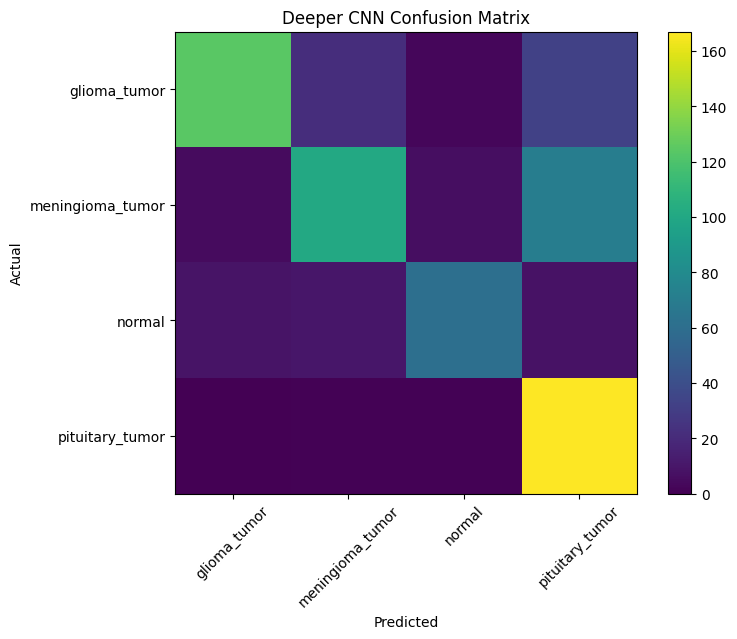

In [35]:
cm_deep = confusion_matrix(y_true, y_pred_deep_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm_deep)
plt.title("Deeper CNN Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Sample prediction for deeper model

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step


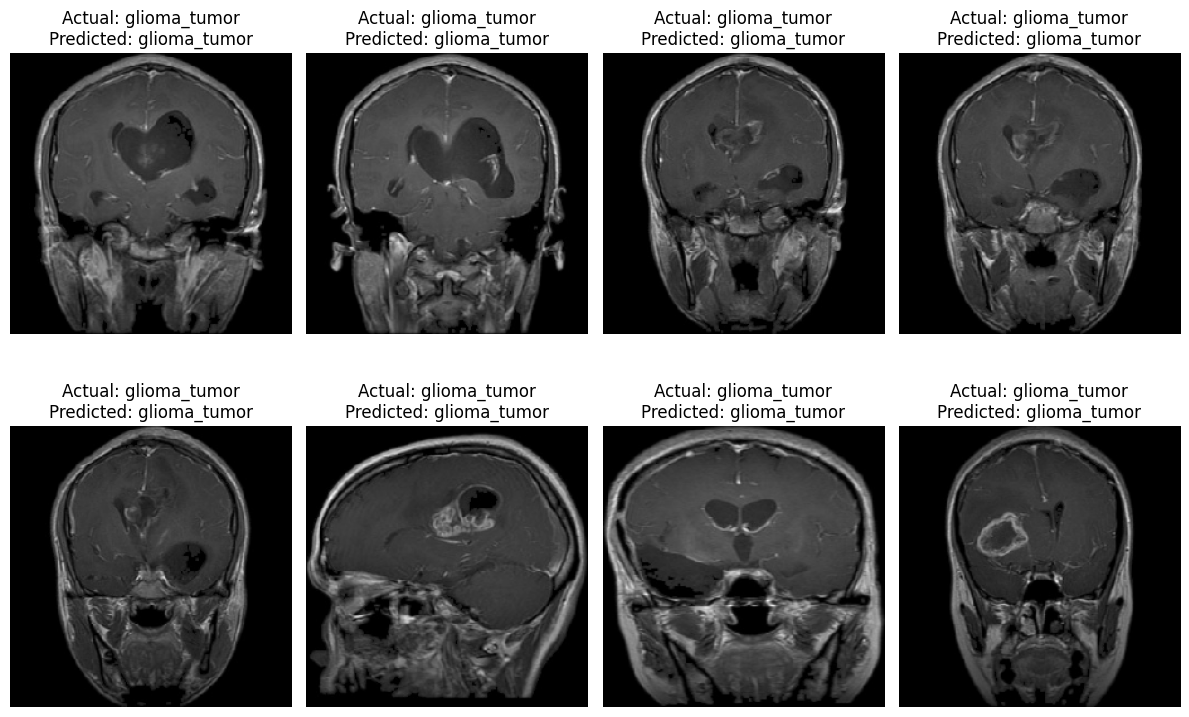

In [36]:
test_generator.reset()
images, labels = next(test_generator)
predictions = deep_model.predict(images)

plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    actual = class_names[np.argmax(labels[i])]
    predicted = class_names[np.argmax(predictions[i])]
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Cell 21: Compare Baseline vs Deeper Model

In [31]:
print("Baseline Accuracy:", baseline_acc)
print("Deeper CNN Accuracy:", deep_acc)

print("Baseline Training Time:", baseline_time)
print("Deeper CNN Training Time:", deep_time)

Baseline Accuracy: 0.8309178948402405
Deeper CNN Accuracy: 0.729468584060669
Baseline Training Time: 765.4058699607849
Deeper CNN Training Time: 848.2767720222473


Cell 22: Comparison Table

In [32]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline CNN", "Deeper CNN with Regularization"],
    "Test Accuracy": [baseline_acc, deep_acc],
    "Test Loss": [baseline_loss, deep_loss],
    "Training Time (seconds)": [baseline_time, deep_time]
})

comparison

,Model,Test Accuracy,Test Loss,Training Time (seconds)
0,Baseline CNN,0.830918,1.086675,765.405870
1,Deeper CNN with Regularization,0.729469,0.790589,848.276772


Cell 23: Save Models

In [33]:
baseline_model.save("baseline_brain_tumor_cnn.h5")
deep_model.save("deep_brain_tumor_cnn.h5")

Cell 24: SGD Optimizer Experiment

In [37]:
from tensorflow.keras.optimizers import SGD

sgd_model = Sequential([

    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(128,activation='relu'),
    Dropout(0.2),

    Dense(num_classes,activation='softmax')
])

sgd_model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

sgd_history = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

sgd_time = time.time() - start_time

test_generator.reset()

sgd_loss, sgd_acc = sgd_model.evaluate(test_generator)

print("SGD Accuracy:", sgd_acc)
print("SGD Loss:", sgd_loss)
print("SGD Training Time:", sgd_time)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 58s 820ms/step - accuracy: 0.4612 - loss: 1.1922 - val_accuracy: 0.3984 - val_loss: 1.3755
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 52s 828ms/step - accuracy: 0.5393 - loss: 1.0796 - val_accuracy: 0.3101 - val_loss: 1.3592
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 47s 763ms/step - accuracy: 0.5776 - loss: 1.0022 - val_accuracy: 0.3347 - val_loss: 1.3159
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 656ms/step - accuracy: 0.5832 - loss: 0.9806 - val_accuracy: 0.3244 - val_loss: 1.3185
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 654ms/step - accuracy: 0.5964 - loss: 0.9551 - val_accuracy: 0.4066 - val_loss: 1.1794
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 624ms/step - accuracy: 0.6332 - loss: 0.9053 - val_accuracy: 0.5893 - val_loss: 1.0952
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 626ms/step - accuracy: 0.6337 - loss: 0.8683 - val_accuracy: 0.4559 - val_loss: 1.0908
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 650ms/step - accuracy: 0.6561 - loss: 0.8563 - val_accu

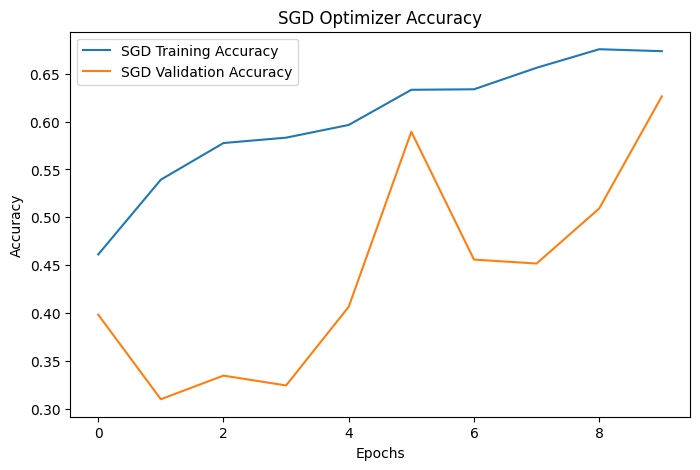

In [41]:
plt.figure(figsize=(8,5))

plt.plot(sgd_history.history['accuracy'], label='SGD Training Accuracy')
plt.plot(sgd_history.history['val_accuracy'], label='SGD Validation Accuracy')

plt.title("SGD Optimizer Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

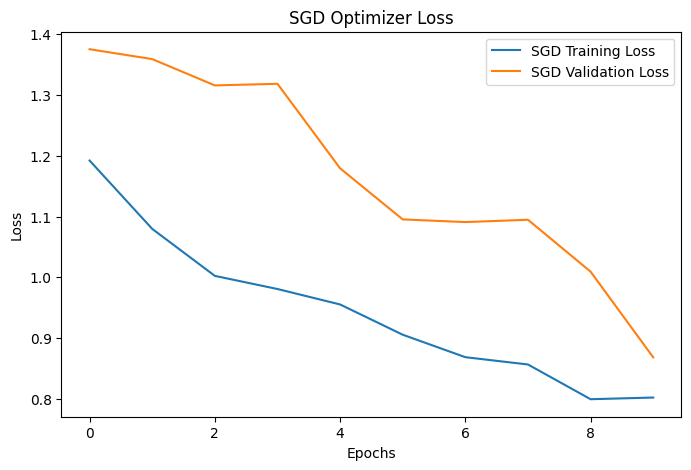

In [42]:
plt.figure(figsize=(8,5))

plt.plot(sgd_history.history['loss'], label='SGD Training Loss')
plt.plot(sgd_history.history['val_loss'], label='SGD Validation Loss')

plt.title("SGD Optimizer Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

Cell 25: Adam vs SGD Comparison Table

In [38]:
optimizer_comparison = pd.DataFrame({

    "Optimizer": ["Adam", "SGD"],

    "Accuracy": [deep_acc, sgd_acc],

    "Loss": [deep_loss, sgd_loss]

})

optimizer_comparison

,Optimizer,Accuracy,Loss
0,Adam,0.729469,0.790589
1,SGD,0.500805,1.154144


Cell 26: Ablation Study (Without Dropout)

In [39]:
ablation_model = Sequential([

    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(256,activation='relu'),

    Dense(128,activation='relu'),

    Dense(num_classes,activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ablation_history = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

test_generator.reset()

ablation_loss, ablation_acc = ablation_model.evaluate(test_generator)

print("Ablation Accuracy:", ablation_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 52s 726ms/step - accuracy: 0.5214 - loss: 1.0908 - val_accuracy: 0.1910 - val_loss: 1.7302
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 628ms/step - accuracy: 0.6224 - loss: 0.8695 - val_accuracy: 0.3552 - val_loss: 1.5415
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 633ms/step - accuracy: 0.6740 - loss: 0.7923 - val_accuracy: 0.4415 - val_loss: 2.0462
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 38s 607ms/step - accuracy: 0.7153 - loss: 0.7014 - val_accuracy: 0.2895 - val_loss: 4.9997
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 630ms/step - accuracy: 0.7168 - loss: 0.6826 - val_accuracy: 0.2772 - val_loss: 6.3379
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 628ms/step - accuracy: 0.7357 - loss: 0.6342 - val_accuracy: 0.3819 - val_loss: 4.8634
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 37s 600ms/step - accuracy: 0.7510 - loss: 0.6049 - val_accuracy: 0.3080 - val_loss: 5.3053
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 625ms/step - accuracy: 0.7566 - loss: 0.6052 - val_accu

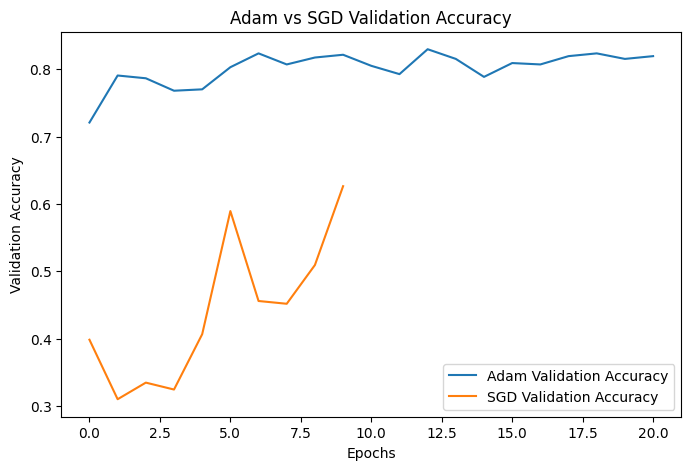

In [43]:
plt.figure(figsize=(8,5))

plt.plot(deep_history.history['val_accuracy'], label='Adam Validation Accuracy')
plt.plot(sgd_history.history['val_accuracy'], label='SGD Validation Accuracy')

plt.title("Adam vs SGD Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

Cell 27: Ablation Comparison Table

In [40]:
ablation_comparison = pd.DataFrame({

    "Model": [
        "Deeper CNN with Dropout",
        "Without Dropout"
    ],

    "Accuracy": [
        deep_acc,
        ablation_acc
    ]
})

ablation_comparison

,Model,Accuracy
0,Deeper CNN with Dropout,0.729469
1,Without Dropout,0.363929


Part B:Transfer Learning

IMPORT VGG16

In [44]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

STEP 2 — LOAD PRETRAINED VGG16

In [45]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


STEP 3 — BUILD TRANSFER LEARNING MODEL

In [47]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

predictions = Dense(num_classes, activation='softmax')(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

STEP 4 — COMPILE MODEL

In [48]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,879,428 (56.76 MB)

 Trainable params: 164,740 (643.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

STEP 5 — TRAIN TRANSFER MODEL

In [49]:
early_stop_transfer = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr_transfer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-7
)

STEP 6 — TRAINING

In [50]:
import time

start_time = time.time()

transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop_transfer, reduce_lr_transfer]
)

transfer_time = time.time() - start_time

print("Transfer Learning Training Time:", transfer_time)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 72s 912ms/step - accuracy: 0.3041 - loss: 1.4153 - val_accuracy: 0.3984 - val_loss: 1.3039 - learning_rate: 1.0000e-04
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 700ms/step - accuracy: 0.3235 - loss: 1.3518 - val_accuracy: 0.4538 - val_loss: 1.2768 - learning_rate: 1.0000e-04
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 685ms/step - accuracy: 0.3561 - loss: 1.3253 - val_accuracy: 0.5072 - val_loss: 1.2515 - learning_rate: 1.0000e-04
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 675ms/step - accuracy: 0.4036 - loss: 1.2854 - val_accuracy: 0.5544 - val_loss: 1.2149 - learning_rate: 1.0000e-04
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 675ms/step - accuracy: 0.4092 - loss: 1.2495 - val_accuracy: 0.5400 - val_loss: 1.1754 - learning_rate: 1.0000e-04
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 657ms/step - accuracy: 0.4510 - loss: 1.2168 - val_accuracy: 0.5524 - val_loss: 1.1327 - learning_rate: 1.0000e-04
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 670ms/step - acc

STEP 7 — FINE TUNING

In [51]:
base_model.trainable = True

for layer in base_model.layers[:-8]:
    layer.trainable = False

STEP 8 — COMPILE AGAIN WITH SMALL LR

In [52]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

STEP 9 — TRAIN AGAIN (FINE TUNING)

In [53]:
fine_tune_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop_transfer, reduce_lr_transfer]
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 74s 955ms/step - accuracy: 0.6816 - loss: 0.7950 - val_accuracy: 0.7598 - val_loss: 0.5987 - learning_rate: 1.0000e-05
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 50s 808ms/step - accuracy: 0.7520 - loss: 0.6537 - val_accuracy: 0.8090 - val_loss: 0.5258 - learning_rate: 1.0000e-05
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 78s 738ms/step - accuracy: 0.8087 - loss: 0.5238 - val_accuracy: 0.8296 - val_loss: 0.4367 - learning_rate: 1.0000e-05
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 706ms/step - accuracy: 0.8367 - loss: 0.4616 - val_accuracy: 0.8049 - val_loss: 0.4761 - learning_rate: 1.0000e-05
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 704ms/step - accuracy: 0.8485 - loss: 0.4222 - val_accuracy: 0.8706 - val_loss: 0.3770 - learning_rate: 1.0000e-05
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 706ms/step - accuracy: 0.8566 - loss: 0.3886 - val_accuracy: 0.8214 - val_loss: 0.4806 - learning_rate: 1.0000e-05
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 711ms/step - acc

STEP 10 — PLOT ACCURACY GRAPH

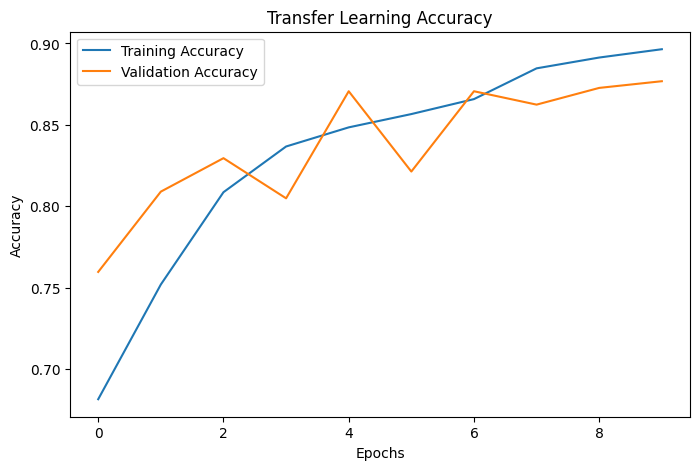

In [54]:
plt.figure(figsize=(8,5))

plt.plot(
    fine_tune_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    fine_tune_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Transfer Learning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

STEP 11 — PLOT LOSS GRAPH

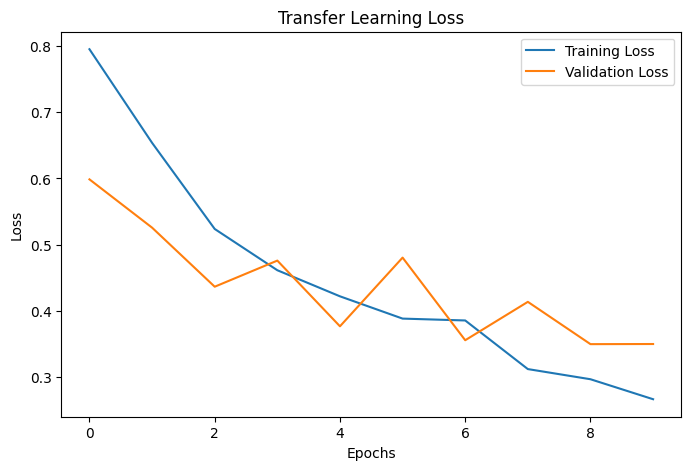

In [55]:
plt.figure(figsize=(8,5))

plt.plot(
    fine_tune_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    fine_tune_history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Transfer Learning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

STEP 12 — EVALUATE MODEL

In [56]:
test_generator.reset()

transfer_loss, transfer_acc = transfer_model.evaluate(test_generator)

print("Transfer Learning Test Accuracy:", transfer_acc)
print("Transfer Learning Test Loss:", transfer_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 503ms/step - accuracy: 0.8921 - loss: 0.3490
Transfer Learning Test Accuracy: 0.8921095132827759
Transfer Learning Test Loss: 0.3490282893180847


STEP 13 — CLASSIFICATION REPORT

In [57]:
from sklearn.metrics import classification_report
import numpy as np

test_generator.reset()

y_pred_transfer = transfer_model.predict(test_generator)

y_pred_transfer_classes = np.argmax(
    y_pred_transfer,
    axis=1
)

y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred_transfer_classes,
    target_names=class_names,
    zero_division=0
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.93      0.90      0.92       181
meningioma_tumor       0.90      0.80      0.84       183
          normal       0.92      0.91      0.91        88
 pituitary_tumor       0.84      0.98      0.90       169

        accuracy                           0.89       621
       macro avg       0.90      0.90      0.89       621
    weighted avg       0.89      0.89      0.89       621



STEP 14 — CONFUSION MATRIX

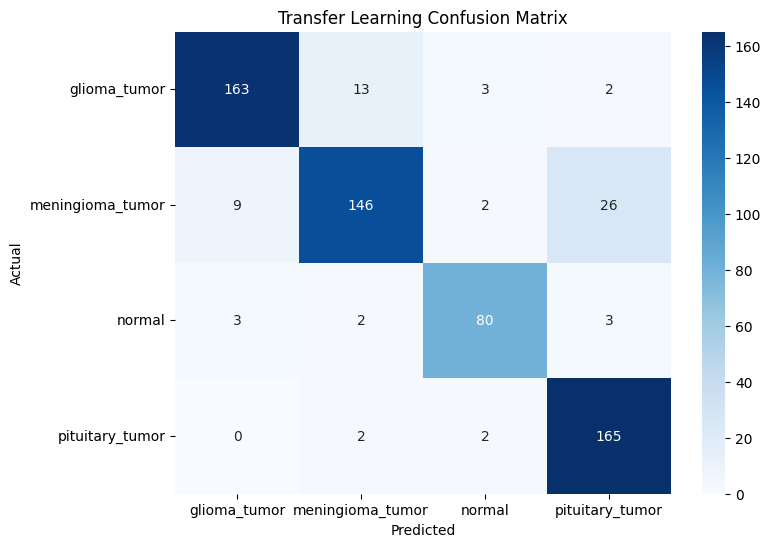

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred_transfer_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transfer Learning Confusion Matrix")

plt.show()

STEP 15 — SAMPLE PREDICTIONS

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step


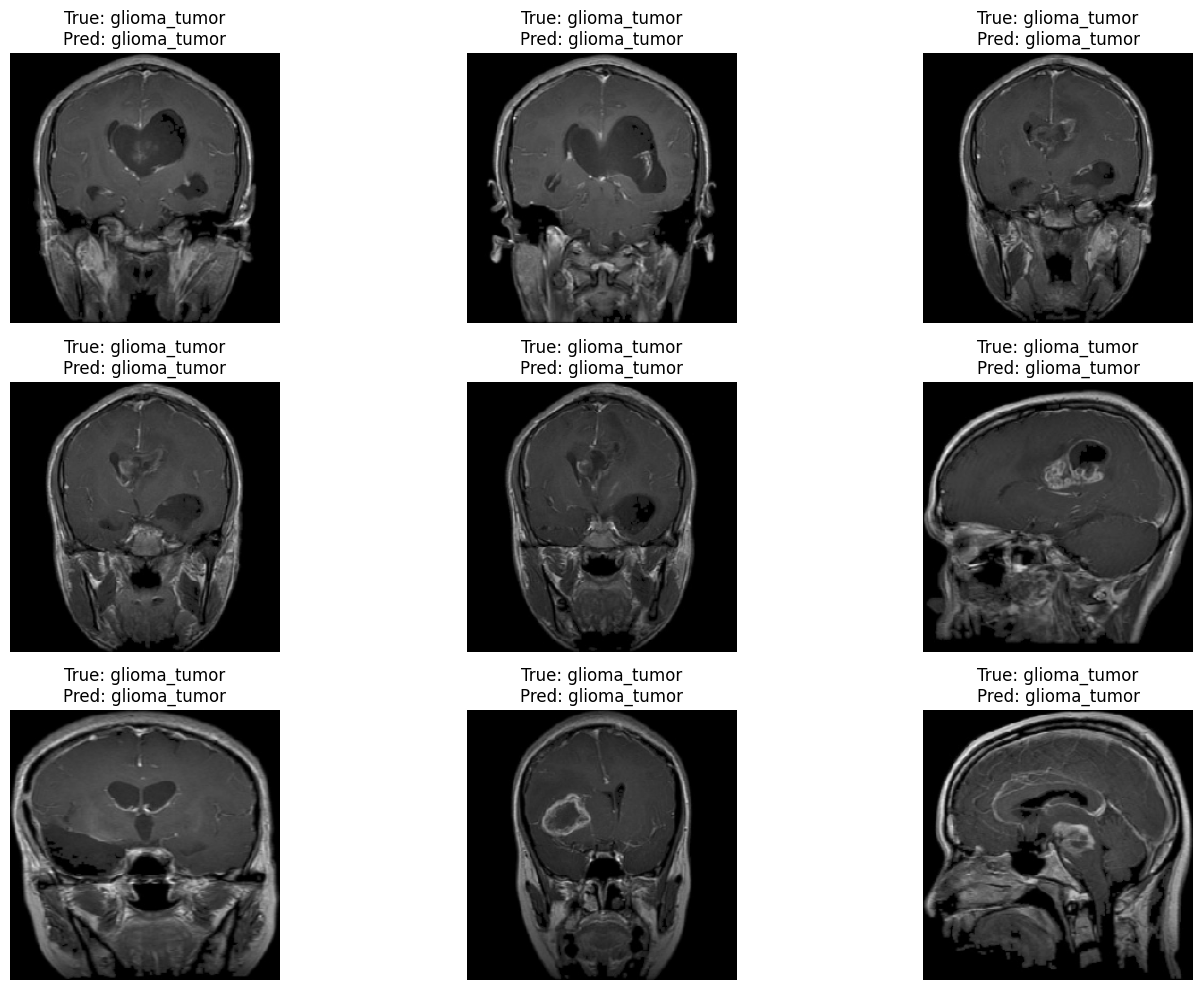

In [59]:
images, labels = next(test_generator)

predictions = transfer_model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(
        f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

STEP 16 — FINAL COMPARISON TABLE

In [60]:
comparison = pd.DataFrame({

    "Model": [
        "Baseline CNN",
        "Deeper CNN",
        "Transfer Learning (VGG16)"
    ],

    "Accuracy": [
        baseline_acc,
        deep_acc,
        transfer_acc
    ],

    "Loss": [
        baseline_loss,
        deep_loss,
        transfer_loss
    ]
})

comparison

,Model,Accuracy,Loss
0,Baseline CNN,0.830918,1.086675
1,Deeper CNN,0.729469,0.790589
2,Transfer Learning (VGG16),0.892110,0.349028


STEP 17 — SAVE MODEL

In [61]:
transfer_model.save("brain_tumor_vgg16_model.h5")